In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# load
df = pd.read_csv('Mall_Customers.csv')   # adjust path if needed
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
Gender
Female    112
Male       88
Name: count, dtype: int64


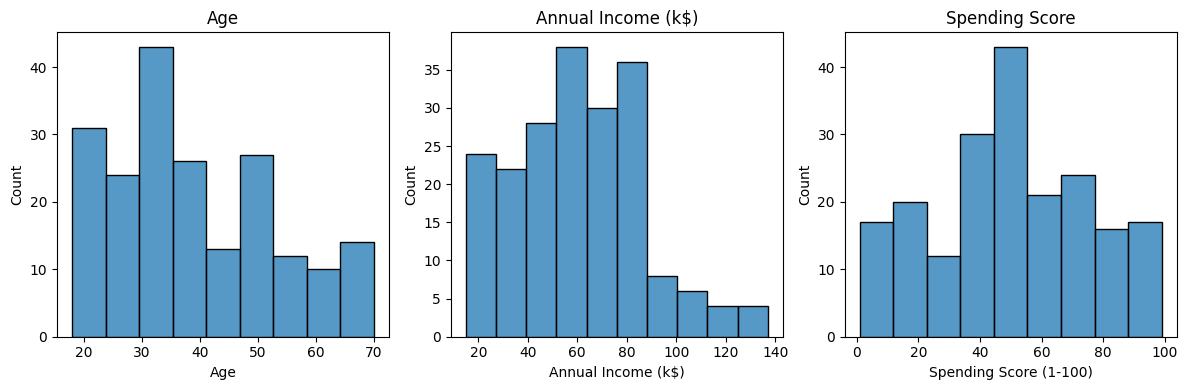

In [2]:
df.info()
df.describe()
df.isnull().sum()

# show value counts for gender (if present)
if 'Gender' in df.columns:
    print(df['Gender'].value_counts())

# distributions
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); sns.histplot(df['Age'], kde=False).set_title('Age')
plt.subplot(1,3,2); sns.histplot(df['Annual Income (k$)'], kde=False).set_title('Annual Income (k$)')
plt.subplot(1,3,3); sns.histplot(df['Spending Score (1-100)'], kde=False).set_title('Spending Score')
plt.tight_layout()


In [3]:
# drop ID
if 'CustomerID' in df.columns:
    df = df.drop(columns=['CustomerID'])

# select features for clustering (2D)
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].copy()

# optional: encode gender if you want to include it
# df['Gender'] = df['Gender'].map({'Male':1,'Female':0})

# scale features (recommended for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


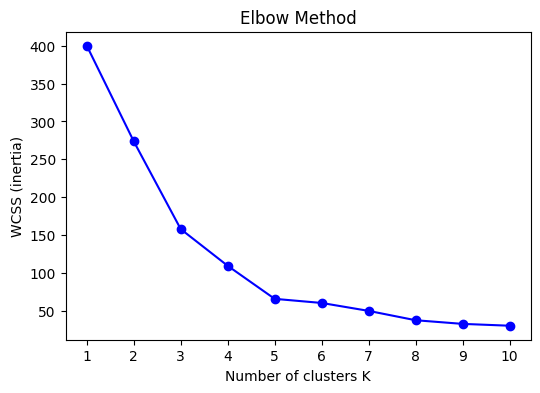

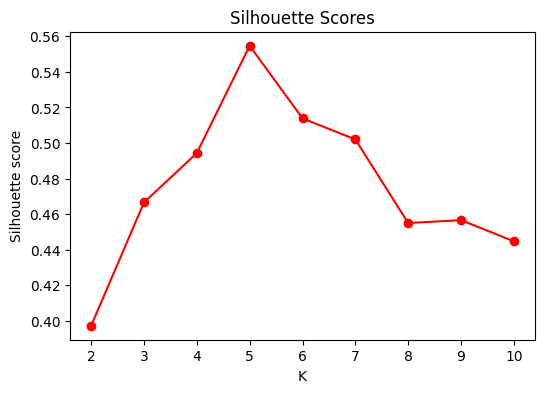

K=2, silhouette=0.397
K=3, silhouette=0.467
K=4, silhouette=0.494
K=5, silhouette=0.555
K=6, silhouette=0.514
K=7, silhouette=0.502
K=8, silhouette=0.455
K=9, silhouette=0.457
K=10, silhouette=0.445


In [4]:
wcss = []
K_range = range(1,11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, wcss, 'bo-')
plt.xlabel('Number of clusters K')
plt.ylabel('WCSS (inertia)')
plt.title('Elbow Method')
plt.xticks(K_range)
plt.show()

# silhouette (for k >= 2)
sil_scores = []
K_range2 = range(2,11)
for k in K_range2:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    sil_scores.append(sil)

plt.figure(figsize=(6,4))
plt.plot(list(K_range2), sil_scores, 'ro-')
plt.xlabel('K')
plt.ylabel('Silhouette score')
plt.title('Silhouette Scores')
plt.show()

# print silhouette values
for k, s in zip(K_range2, sil_scores):
    print(f'K={k}, silhouette={s:.3f}')


In [5]:
chosen_k = 5
kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_scaled)

# attach labels (0..k-1) to original dataframe
df_clusters = df.copy()
df_clusters['Cluster'] = cluster_labels

# if you want centroids in original feature space:
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids, columns=X.columns)
centroids_df


,Annual Income (k$),Spending Score (1-100)
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


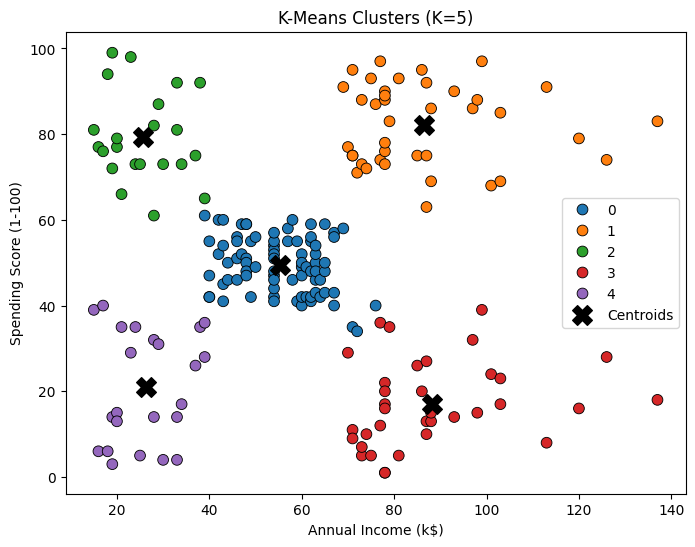

In [6]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df_clusters['Annual Income (k$)'],
    y=df_clusters['Spending Score (1-100)'],
    hue=df_clusters['Cluster'],
    palette='tab10',
    s=60,
    edgecolor='k'
)
# plot centroids
plt.scatter(centroids_df['Annual Income (k$)'], centroids_df['Spending Score (1-100)'],
            marker='X', s=200, c='black', label='Centroids')
plt.title(f'K-Means Clusters (K={chosen_k})')
plt.legend()
plt.show()


In [7]:
# counts per cluster
print(df_clusters['Cluster'].value_counts().sort_index())

# mean values per cluster (for interpretation)
cluster_summary = df_clusters.groupby('Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean().round(2)
cluster_counts = df_clusters.groupby('Cluster').size().rename('Count')
cluster_summary = cluster_summary.join(cluster_counts)
cluster_summary


Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


,Age,Annual Income (k$),Spending Score (1-100),Count
Cluster,,,,
0,42.72,55.30,49.52,81
1,32.69,86.54,82.13,39
2,25.27,25.73,79.36,22
3,41.11,88.20,17.11,35
4,45.22,26.30,20.91,23


In [8]:
df_clusters.to_csv('mall_customers_with_clusters.csv', index=False)


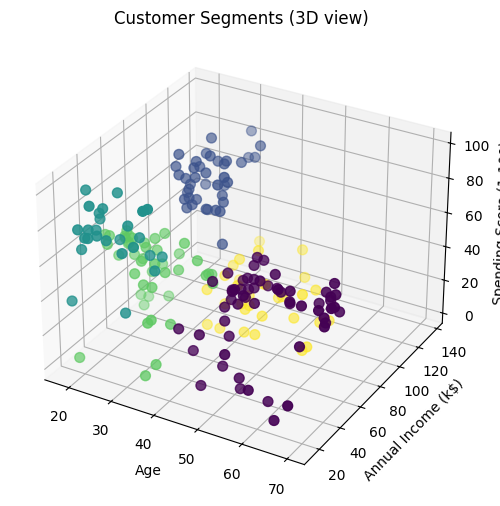

In [9]:
from mpl_toolkits.mplot3d import Axes3D

# Select 3 features
X3 = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

# Scale them
X3_scaled = scaler.fit_transform(X3)

# Fit KMeans
kmeans3 = KMeans(n_clusters=5, random_state=42)
df['Cluster3'] = kmeans3.fit_predict(X3_scaled)

# 3D visualization
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['Age'], df['Annual Income (k$)'], df['Spending Score (1-100)'],
           c=df['Cluster3'], cmap='viridis', s=50)

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
plt.title("Customer Segments (3D view)")
plt.show()
